# Poverty as a Signal for County-Level Health Outcomes in Indiana

Predicting three county-level health outcomes from economic and structural conditions across all 92 Indiana counties, using ACS (predictors) and CDC PLACES (outcomes), joined on county FIPS.

**Pipeline:** load → clean ACS → build predictors → clean PLACES → merge → model (5-fold CV) → choropleth.

*Note: file paths are local. Update the `read_csv` / `read_file` paths to reproduce.*

## 1. Load data

ACS poverty table (predictors), PLACES county health data (outcomes), and a FIPS crosswalk to attach county codes to ACS county names.

In [1]:
import pandas as pd

# ACS poverty table — county-level economic/structural indicators (predictors)
df = pd.read_csv(r"C:\Users\ibrah\Downloads\ACSST5Y2023.S1701-2026-05-20T065728.csv")

# CDC PLACES — county-level health outcome prevalence (targets)
pl_df = pd.read_csv(r"C:\Users\ibrah\Downloads\PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260520.csv", low_memory=False)

# FIPS crosswalk — maps county name to 5-digit FIPS code
fips_ref = pd.read_csv('https://raw.githubusercontent.com/kjhealy/fips-codes/master/state_and_county_fips_master.csv')

## 2. Reshape ACS from wide to long

The ACS export is transposed: indicators are rows, counties are columns. Transpose so each row is a county-category-statistic combination, then split the compound label (`County!!Category!!Statistic`) into separate columns.

In [2]:
# Transpose: indicators become columns, county/category/stat combinations become rows
df = df.set_index('Label (Grouping)').T.reset_index()

# The 'index' column holds a compound label like 'Adams County, Indiana!!Total!!Estimate'
# Split it on '!!' into county, poverty_category, and stat
df[['county', 'poverty_category', 'stat']] = df['index'].str.split('!!', expand=True)
df = df.drop('index', axis=1)

## 3. Attach FIPS codes to ACS

Split the county string off the state, then merge against the Indiana slice of the FIPS crosswalk to attach county codes.

In [3]:
# Separate county name from state, strip whitespace for a clean join key
df[['county', 'state']] = df['county'].str.split(',', expand=True)
df['county'] = df['county'].str.strip()

# Restrict crosswalk to Indiana (92 counties) and merge to attach FIPS
fips_ref = fips_ref[fips_ref['state'] == 'IN']
df = fips_ref.merge(df, how='left', left_on='name', right_on='county')

## 4. Clean column names

ACS column names carry non-breaking spaces (`\xa0`) and indentation from the original HTML table. Normalize all whitespace so columns can be referenced by their clean names.

In [4]:
# Collapse any whitespace run (incl. non-breaking spaces) to a single space, then strip
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

## 5. Build the two structural predictors

`elderly_pct` and `over_16_labor_force_pct` are rates, built from raw counts on the **Total** poverty-category rows. Counts are stored as comma-formatted strings, so they're stripped and converted before dividing.

- **elderly share** = 65+ / population for whom poverty status is determined
- **labor force ratio** = civilian labor force 16+ / population 18-64. This is a proxy, not the official
  participation rate (which divides by everyone 16+), so values run higher (73% to 93%).

In [5]:
# Work from the 'Total' rows — these hold county-wide counts, not poverty-sliced ones
wdf = df[df['poverty_category'] == 'Total'].copy()

# Counts arrive as comma-formatted strings ('35,459') — strip commas, convert to numeric
for col in ['Population for whom poverty status is determined', '65 years and over',
            'Civilian labor force 16 years and over', '18 to 64 years']:
    wdf[col] = pd.to_numeric(wdf[col].str.replace(',', ''), errors='coerce')

# Convert counts into rates so the model reads concentration, not county size
wdf['elderly_pct'] = (wdf['65 years and over'] / wdf['Population for whom poverty status is determined']) * 100
wdf['over_16_labor_force_pct'] = (wdf['Civilian labor force 16 years and over'] / wdf['18 to 64 years']) * 100

## 6. Assemble the ACS predictor frame

The poverty rate lives on a different row (`Percent below poverty level`) than the two rate predictors (`Total`). Pull each from its row, then merge on FIPS into one clean per-county frame.

In [6]:
# Predictors built on the Total rows — keep one Estimate row per county
wdf = wdf[wdf['stat'] == 'Estimate']
kdf = wdf[['fips', 'elderly_pct', 'over_16_labor_force_pct']].copy()

# Poverty rate lives on the 'Percent below poverty level' / Estimate row
pov = df[(df['poverty_category'] == 'Percent below poverty level') & (df['stat'] == 'Estimate')]
ndf = pov[['fips', 'name', 'Population for whom poverty status is determined']].copy()

# Combine the two into one per-county predictor frame
df = kdf.merge(ndf, how='right', on='fips')

In [7]:
# The 'Population for whom poverty status is determined' column on this row actually holds
# the poverty RATE (a percentage), not a count. Strip '%', convert, and rename to reflect that.
df['Population for whom poverty status is determined'] = pd.to_numeric(
    df['Population for whom poverty status is determined'].str.replace('%', ''),
    errors='coerce'
)
df = df.rename(columns={'Population for whom poverty status is determined': 'poverty_rate'})

## 7. Clean and filter PLACES

Normalize the `Measure` strings (same `\xa0` issue), then filter to Indiana, 2023, **crude prevalence** (age kept in the outcome so `elderly_pct` does real work), and the three chosen health outcomes.

In [8]:
# Normalize measure names (non-breaking spaces) so the measure filter matches cleanly
pl_df['Measure'] = pl_df['Measure'].str.replace('\xa0', ' ', regex=False).str.strip()

# Filter to Indiana, 2023, crude prevalence (not age-adjusted)
pl = pl_df[(pl_df['StateAbbr'] == 'IN') &
           (pl_df['Year'] == 2023) &
           (pl_df['Data_Value_Type'] == 'Crude prevalence')].copy()

# Keep only the columns needed downstream
pl = pl[['LocationID', 'Measure', 'Data_Value', 'Geolocation']].copy()

# Select the three target health outcomes
keep_msr = ['Fair or poor self-rated health status among adults',
            'Diagnosed diabetes among adults',
            'Frequent mental distress among adults']
pl = pl[pl['Measure'].isin(keep_msr)].copy()

print(pl['Measure'].value_counts())   # expect 92 each → 276 rows total

Measure
Fair or poor self-rated health status among adults    92
Diagnosed diabetes among adults                       92
Frequent mental distress among adults                 92
Name: count, dtype: int64


## 8. Merge predictors with outcomes, pivot to wide

Join PLACES (long: one row per county-measure) onto the ACS predictors by FIPS, then pivot so each county is one row with the three outcomes as columns. Deduplicate the predictor side (identical across a county's measure rows) before re-attaching the pivoted outcomes.

In [9]:
# Join PLACES long-format onto ACS predictors by FIPS
working_df = pl.merge(df, how='left', left_on='LocationID', right_on='fips')
working_df = working_df.drop('LocationID', axis=1)

# Pivot outcomes wide: one row per county, each measure its own column
pivot_df = working_df.pivot(index='fips', columns='Measure', values='Data_Value').reset_index()

# Collapse the predictor side to one row per county (identical across measure rows),
# then attach the wide outcome columns
working_df = working_df.drop(columns=['Measure', 'Data_Value']).drop_duplicates(subset='fips')
final_df = working_df.merge(pivot_df, how='left', on='fips')
print(final_df.shape)   # expect 92 rows

(92, 9)


## 9. Sanity checks

Confirm one county reads correctly and the predictors are clean (no nulls, sensible ranges) before modeling.

In [10]:
# Spot-check a single county against known values
print(final_df[final_df['fips'] == 18001][['fips', 'poverty_rate', 'elderly_pct',
    'Fair or poor self-rated health status among adults']])

# Predictor distributions and null check
print(final_df[['poverty_rate', 'elderly_pct', 'over_16_labor_force_pct']].describe())
print(final_df[['poverty_rate', 'elderly_pct', 'over_16_labor_force_pct']].isnull().sum())

     fips  poverty_rate  elderly_pct  \
59  18001          12.4    15.144251   

    Fair or poor self-rated health status among adults  
59                                               24.1   
       poverty_rate  elderly_pct  over_16_labor_force_pct
count     92.000000    92.000000                92.000000
mean      11.714130    18.188056                85.479707
std        3.730203     2.237523                 3.551316
min        4.300000    12.564392                72.897811
25%        9.275000    16.959118                83.213419
50%       11.850000    18.324176                85.541679
75%       13.425000    19.710739                87.692121
max       23.800000    25.916982                92.569796
poverty_rate               0
elderly_pct                0
over_16_labor_force_pct    0
dtype: int64


## 10. Model: repeated 5-fold cross-validated linear regression

Three predictors, three outcomes modeled separately. With only 92 counties, a single
train/test split would leave about 18 test counties, so I use 5-fold cross-validation.

A single 5-fold split is still sensitive to which counties land in which fold (one fold
can score above 0.7 and another below 0), so the folds are shuffled and the whole
procedure is repeated 50 times with a fixed seed. Reported: mean R² and the standard
deviation across all 250 folds.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, RepeatedKFold

regression = LinearRegression()
cv = RepeatedKFold(n_splits=5, n_repeats=50, random_state=0)

predictors = final_df[['poverty_rate', 'elderly_pct', 'over_16_labor_force_pct']]
targets = ['Diagnosed diabetes among adults',
           'Frequent mental distress among adults',
           'Fair or poor self-rated health status among adults']

for x in targets:
    target = final_df[x]
    scores = cross_val_score(regression, predictors, target, cv=cv, scoring='r2')
    print(f'{x}: mean R2 = {scores.mean():.3f}, std across folds = {scores.std():.3f}')

Diagnosed diabetes among adults: mean R2 = 0.496, std across folds = 0.225


Frequent mental distress among adults: mean R2 = 0.418, std across folds = 0.263


Fair or poor self-rated health status among adults: mean R2 = 0.378, std across folds = 0.336


## 11. What drives each outcome

Two checks: how much each predictor explains on its own (in-sample R²), and standardized
coefficients (predictors and outcome rescaled to standard deviations), so the size of each
predictor's effect can be compared within an outcome.

In [12]:
rows = []
for x in targets:
    y = final_df[x]
    row = {'outcome': x}
    for col in predictors.columns:
        row[f'R2 {col} alone'] = LinearRegression().fit(predictors[[col]], y).score(predictors[[col]], y)
    row['R2 all three'] = regression.fit(predictors, y).score(predictors, y)
    rows.append(row)
print(pd.DataFrame(rows).set_index('outcome').round(2).T)

# Standardized coefficients: change in outcome (in SDs) per 1 SD change in each predictor
z = (predictors - predictors.mean()) / predictors.std()
coefs = {}
for x in targets:
    y = final_df[x]
    coefs[x] = regression.fit(z, (y - y.mean()) / y.std()).coef_
print(pd.DataFrame(coefs, index=predictors.columns).round(2))

outcome                           Diagnosed diabetes among adults  \
R2 poverty_rate alone                                        0.25   
R2 elderly_pct alone                                         0.38   
R2 over_16_labor_force_pct alone                             0.30   
R2 all three                                                 0.61   

outcome                           Frequent mental distress among adults  \
R2 poverty_rate alone                                              0.50   
R2 elderly_pct alone                                               0.00   
R2 over_16_labor_force_pct alone                                   0.38   
R2 all three                                                       0.55   

outcome                           Fair or poor self-rated health status among adults  
R2 poverty_rate alone                                                          0.38   
R2 elderly_pct alone                                                           0.14   
R2 over_16_labor_

**Result:** The three outcomes are driven by different things.

- **Frequent mental distress** tracks poverty most closely. Poverty alone explains about half
  the variation, and it has the largest standardized coefficient.
- **Diagnosed diabetes** tracks age most closely. Elderly share has the largest coefficient,
  and poverty adds little once age and the labor force ratio are in the model. This is
  partly because crude prevalence keeps age in the outcome.
- **Fair or poor self-rated health** sits in between, with poverty, age, and the labor force
  ratio all contributing.

**Data caveat:** CDC PLACES values are not direct survey counts. They are model estimates
(multilevel regression and poststratification) built from BRFSS survey responses, and that
model uses individual age and county poverty (share of adults below 150% of the federal
poverty level, from the ACS) as inputs. So part of the poverty and age relationship found
here is built into the outcome data itself. The results describe how these county
estimates line up with poverty, not an independent test of poverty's effect.

## 12. Choropleth — self-rated health by county

Load Indiana county geometry, build the 5-digit FIPS key on both sides, join the data onto the polygons, and map observed fair/poor self-rated health. Lighter = better health.

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load US county polygons, build 5-digit FIPS, filter to Indiana (STATEFP 18)
counties = gpd.read_file(r"C:\Users\ibrah\Downloads\tl_2023_us_county\tl_2023_us_county.shp")
counties['fips'] = counties['STATEFP'] + counties['COUNTYFP']
in_counties = counties[counties['STATEFP'] == '18'].copy()

# Match FIPS format on the data side, then join onto geometry (GeoDataFrame on the left)
final_df['fips'] = final_df['fips'].astype('str').str.zfill(5)
geo = in_counties.merge(final_df, on='fips', how='left')

C:\Users\ibrah\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [14]:
# Verify the join: row count, geometry preserved, no missing outcome values
print(geo.shape)
print(type(geo))
print('null outcomes:', geo['Fair or poor self-rated health status among adults'].isnull().sum())

(92, 28)
<class 'geopandas.geodataframe.GeoDataFrame'>
null outcomes: 0


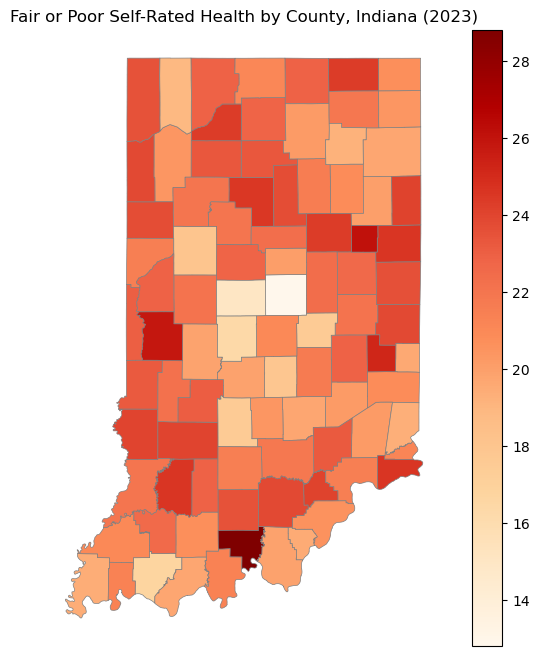

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
geo.plot(
    column='Fair or poor self-rated health status among adults',
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='grey',
    legend=True,
    ax=ax
)
ax.set_title('Fair or Poor Self-Rated Health by County, Indiana (2023)')
ax.axis('off')
plt.savefig('srh_choropleth.png', dpi=150, bbox_inches='tight')
plt.show()